# Mirror Thermal Tracking During the Night

Plots the air-to-mirror temperature difference ΔT = T_air − T_mirror during
the observing night, where:

- **T_air** = dome air near the mirror (ESS index 113, M1M3 vicinity)
- **T_mirror** = mirror bulk temperature proxy (`temperatureItem10`, ESS index 115)

A large positive ΔT means the air is warmer than the mirror (mirror lag after cooling).
A large negative ΔT means the mirror is warmer than the surrounding air (residual heat load).
The goal is ΔT ≈ 0 throughout the night to minimise seeing-degrading mirror turbulence.

**Reference time t₀:** evening nautical twilight (sun altitude = −12°) at Cerro Pachón

## Data sources
| Source | Topic / index | Field | Quantity |
|---|---|---|---|
| EFD | `lsst.sal.ESS.temperature`, index 113 | all `temperature*` fields | M1M3 vicinity air temp |
| EFD | `lsst.sal.ESS.temperature`, index 115 | `temperatureItem10` | Mirror bulk temperature proxy |

## Imports

In [2]:
import datetime
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

from astropy.time import Time, TimeDelta
import astropy.units as u
from astropy.coordinates import get_sun, AltAz, EarthLocation

from lsst_efd_client import EfdClient

%matplotlib inline

## Configuration

In [3]:
# ── Observatory location ──────────────────────────────────────────────────────
RUBIN_LAT = -30.2444   # deg
RUBIN_LON = -70.7494   # deg
RUBIN_ELV =  2663.0    # m
rubin_loc = EarthLocation(lat=RUBIN_LAT * u.deg,
                          lon=RUBIN_LON * u.deg,
                          height=RUBIN_ELV * u.m)

# ── Temperature sensors ───────────────────────────────────────────────────────
TEMP_TOPIC = "lsst.sal.ESS.temperature"

# Dome air temperature near the mirror
AIR_INDEX   = 113
AIR_LABEL   = "M1M3 vicinity air"

# Mirror bulk temperature proxy
MIRROR_INDEX = 115
MIRROR_FIELD = "temperatureItem10"   # mirror bulk proxy
MIRROR_LABEL = "Mirror (ESS:115 item10)"

# ── Plot window ───────────────────────────────────────────────────────────────
# Hours after t₀ to show (full observing night ~10 h)
PLOT_HOURS_BEFORE_T0 = 0.5    # short pre-t0 context
PLOT_HOURS_AFTER_T0  = 10.0

RESAMPLE_FREQ = "5min"

# ── Single-night example ──────────────────────────────────────────────────────
SINGLE_NIGHT_DATE = "2026-03-15"

# ── Multi-night range ─────────────────────────────────────────────────────────
MULTI_NIGHT_END   = "2026-05-07"   # last night (inclusive)
MULTI_NIGHT_WEEKS = 8

print("Configuration loaded.")

Configuration loaded.


## Connect to EFD

In [4]:
client = EfdClient("usdf_efd")
print("Connected to EFD")

Connected to EFD


## Helper Functions

In [5]:
def evening_nautical_twilight(night_date_str):
    """Return UTC Time of evening nautical twilight (sun alt = −12°)."""
    t_start_search = Time(f"{night_date_str}T19:00:00", scale="utc")
    times = t_start_search + np.linspace(0, 10, 10_000) * u.hour
    frame   = AltAz(obstime=times, location=rubin_loc)
    sun_alt = get_sun(times).transform_to(frame).alt.deg
    mask_above = sun_alt > -12.0
    crossings  = np.where(np.diff(mask_above.astype(int)) < 0)[0]
    if len(crossings) == 0:
        warnings.warn(f"No nautical twilight found for {night_date_str}")
        return None
    i      = crossings[0]
    dt_sec = (times[i + 1] - times[i]).to(u.s).value
    frac   = (-12.0 - sun_alt[i]) / (sun_alt[i + 1] - sun_alt[i])
    return times[i] + TimeDelta(frac * dt_sec * u.s)


def mean_temp_cols(df):
    """Mean of all temperature* columns in a DataFrame."""
    cols = [c for c in df.columns if "temperature" in c.lower()]
    if not cols:
        raise ValueError(f"No temperature columns found. Available: {list(df.columns)}")
    return df[cols].mean(axis=1)


async def fetch_mirror_tracking(t_start, t_end):
    """
    Fetch air (ESS:113) and mirror (ESS:115 temperatureItem10) temperatures
    for the given window.  Returns (air_series, mirror_series) resampled to
    RESAMPLE_FREQ, both with UTC-aware DatetimeIndex.
    """
    # Air temperature near mirror
    df_air = await client.select_time_series(
        TEMP_TOPIC, fields="*", start=t_start, end=t_end, index=AIR_INDEX
    )
    if df_air.empty:
        raise RuntimeError(f"No air temperature data for ESS index {AIR_INDEX}.")
    air = mean_temp_cols(df_air).resample(RESAMPLE_FREQ).mean().rename(AIR_LABEL)
    print(f"  ESS:{AIR_INDEX} ({AIR_LABEL}): {len(df_air)} raw rows")

    # Mirror temperature
    df_mir = await client.select_time_series(
        TEMP_TOPIC, fields=[MIRROR_FIELD], start=t_start, end=t_end, index=MIRROR_INDEX
    )
    if df_mir.empty:
        raise RuntimeError(f"No mirror temperature data for ESS index {MIRROR_INDEX} field {MIRROR_FIELD}.")
    mirror = df_mir[MIRROR_FIELD].resample(RESAMPLE_FREQ).mean().rename(MIRROR_LABEL)
    print(f"  ESS:{MIRROR_INDEX} ({MIRROR_LABEL}): {len(df_mir)} raw rows")

    return air, mirror


print("Helpers defined.")

Helpers defined.


---
## Single Night — Air-to-Mirror ΔT vs Hours After Nautical Twilight

In [5]:
t0_single = evening_nautical_twilight(SINGLE_NIGHT_DATE)
print(f"Evening nautical twilight (t₀): {t0_single.iso} UTC")

t_start_single = t0_single - TimeDelta(PLOT_HOURS_BEFORE_T0 * u.hour)
t_end_single   = t0_single + TimeDelta(PLOT_HOURS_AFTER_T0  * u.hour)
print(f"Query window: {t_start_single.iso}  →  {t_end_single.iso} UTC")

print("\nFetching temperatures…")
air_single, mirror_single = await fetch_mirror_tracking(t_start_single, t_end_single)

Evening nautical twilight (t₀): 2026-03-15 23:51:51.551 UTC
Query window: 2026-03-15 23:21:51.551  →  2026-03-16 09:51:51.551 UTC

Fetching temperatures…
  ESS:113 (M1M3 vicinity air): 26227 raw rows
  ESS:115 (Mirror (ESS:115 item10)): 6972 raw rows


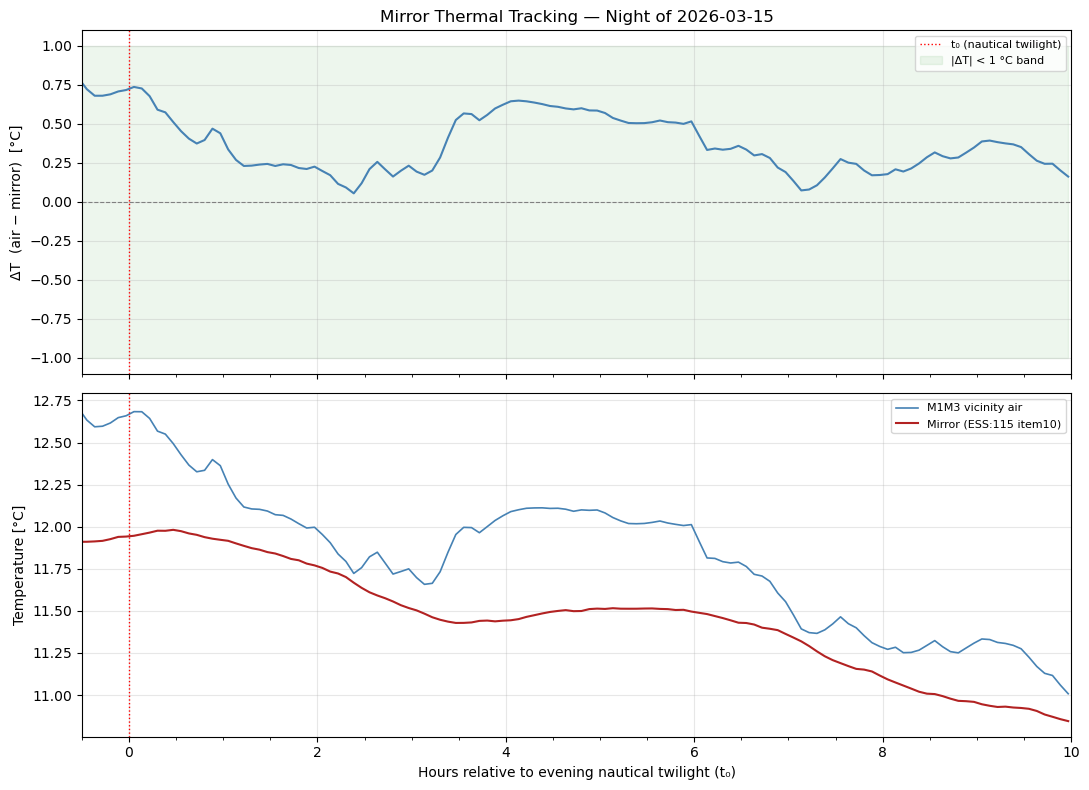

ΔT at t₀ = +0.72 °C
Mean |ΔT| during night = 0.38 °C


In [6]:
# ── Compute ΔT ────────────────────────────────────────────────────────────────
common_idx = air_single.index.intersection(mirror_single.index)
dT_single  = (air_single.reindex(common_idx) - mirror_single.reindex(common_idx)).dropna()

t0_py = t0_single.to_datetime(timezone=datetime.timezone.utc)
hours = np.asarray(
    (dT_single.index.tz_convert("UTC") - t0_py) / pd.Timedelta(hours=1),
    dtype=float
)
air_hours = np.asarray(
    (air_single.index.tz_convert("UTC") - t0_py) / pd.Timedelta(hours=1),
    dtype=float
)
mir_hours = np.asarray(
    (mirror_single.index.tz_convert("UTC") - t0_py) / pd.Timedelta(hours=1),
    dtype=float
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax_dT, ax_T) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Top panel: ΔT
ax_dT.plot(hours, dT_single.values, lw=1.5, color="steelblue")
ax_dT.axhline(0,  color="gray", lw=0.8, ls="--")
ax_dT.axvline(0,  color="red",  lw=1.0, ls=":", label="t₀ (nautical twilight)")
ax_dT.fill_between(hours, -1, 1, where=np.ones_like(hours, dtype=bool),
                   color="green", alpha=0.07, label="|ΔT| < 1 °C band")
ax_dT.set_ylabel("ΔT  (air − mirror)  [°C]", fontsize=10)
ax_dT.set_title(f"Mirror Thermal Tracking — Night of {SINGLE_NIGHT_DATE}", fontsize=12)
ax_dT.legend(fontsize=8, loc="upper right")
ax_dT.grid(True, alpha=0.3)

# Bottom panel: absolute temperatures
ax_T.plot(air_hours, air_single.values,    lw=1.2, color="steelblue",  label=AIR_LABEL)
ax_T.plot(mir_hours, mirror_single.values, lw=1.5, color="firebrick",  label=MIRROR_LABEL)
ax_T.axvline(0, color="red", lw=1.0, ls=":")
ax_T.set_ylabel("Temperature [°C]", fontsize=10)
ax_T.set_xlabel("Hours relative to evening nautical twilight (t₀)", fontsize=10)
ax_T.legend(fontsize=8, loc="upper right")
ax_T.grid(True, alpha=0.3)

for ax in (ax_dT, ax_T):
    ax.set_xlim(-PLOT_HOURS_BEFORE_T0, PLOT_HOURS_AFTER_T0)
    ax.xaxis.set_major_locator(plt.MultipleLocator(2))
    ax.xaxis.set_minor_locator(plt.MultipleLocator(0.5))

plt.tight_layout()
plt.savefig(f"Mirror_tracking_single_{SINGLE_NIGHT_DATE}.pdf", dpi=150, bbox_inches="tight")
plt.show()

idx_t0 = np.argmin(np.abs(hours))
print(f"ΔT at t₀ = {dT_single.iloc[idx_t0]:+.2f} °C")
print(f"Mean |ΔT| during night = {np.abs(dT_single.values).mean():.2f} °C")

### Single-night interpretation

The two-panel plot shows:

- **Top panel (ΔT):** The air-to-mirror temperature difference throughout the observing night.  The green shaded band (−1 to +2 °C) marks the target operating range — within this band the thermal gradient between the mirror surface and the surrounding air is small enough that mirror-induced seeing turbulence is subdominant.
- **Bottom panel (absolute temperatures):** The raw air and mirror temperature traces, useful for diagnosing whether the signal is driven by rapidly changing air (e.g. dome opening shock) or a slowly responding mirror.

**Physical interpretation:**
A positive ΔT at t₀ means the mirror's thermal mass has not yet cooled to ambient — the air cools faster than the mirror after sunset.  This is the most common pattern and typically self-corrects over 2–4 hours as the mirror equilibrates.  A negative ΔT (mirror warmer than air) can indicate residual heat load from the previous afternoon (e.g. insufficient daytime mirror cooling) or radiative cooling of the air outpacing the mirror.


---
## Multiple Nights — Overlay of ΔT Profiles

Each night's air-to-mirror ΔT curve is interpolated onto a common hour grid and
overlaid.  The nightly median and percentile envelopes are overplotted.

In [6]:
t_end_multi   = Time(f"{MULTI_NIGHT_END}T00:00:00", scale="utc")
t_start_multi = t_end_multi - TimeDelta(MULTI_NIGHT_WEEKS * 7 * u.day)

night_dates = [
    (t_start_multi + TimeDelta(i * u.day)).strftime("%Y-%m-%d")
    for i in range(MULTI_NIGHT_WEEKS * 7 + 1)
]
print(f"Processing {len(night_dates)} nights: {night_dates[0]} → {night_dates[-1]}")

Processing 57 nights: 2026-03-12 → 2026-05-07


In [7]:
import asyncio

H_GRID      = np.linspace(-PLOT_HOURS_BEFORE_T0, PLOT_HOURS_AFTER_T0, 500)
_BATCH_SIZE = 8

all_dT_mirror   = {}   # night -> interpolated ΔT on H_GRID
dT_mirror_at_t0 = {}   # night -> ΔT at h=0


async def _process_night(night):
    t0 = evening_nautical_twilight(night)
    if t0 is None:
        return night, None, None
    t_s = t0 - TimeDelta(PLOT_HOURS_BEFORE_T0 * u.hour)
    t_e = t0 + TimeDelta(PLOT_HOURS_AFTER_T0  * u.hour)
    try:
        air, mirror = await fetch_mirror_tracking(t_s, t_e)
    except Exception:
        return night, None, None
    common = air.index.intersection(mirror.index)
    if len(common) < 10:
        return night, None, None
    dT    = (air.reindex(common) - mirror.reindex(common)).dropna()
    t0_py = t0.to_datetime(timezone=datetime.timezone.utc)
    hrs   = np.asarray((dT.index.tz_convert("UTC") - t0_py) / pd.Timedelta(hours=1), dtype=float)
    dT_v  = np.asarray(dT.values, dtype=float)
    sort_idx  = np.argsort(hrs)
    interped  = np.interp(H_GRID, hrs[sort_idx], dT_v[sort_idx], left=np.nan, right=np.nan)
    val_at_t0 = float(np.interp(0.0, hrs[sort_idx], dT_v[sort_idx], left=np.nan, right=np.nan))
    return night, interped, val_at_t0


for batch_start in range(0, len(night_dates), _BATCH_SIZE):
    batch = night_dates[batch_start : batch_start + _BATCH_SIZE]
    results = await asyncio.gather(*[_process_night(n) for n in batch],
                                   return_exceptions=True)
    for res in results:
        if isinstance(res, BaseException):
            continue
        night, interped, val_at_t0 = res
        if interped is not None:
            all_dT_mirror[night]   = interped
            dT_mirror_at_t0[night] = val_at_t0
            print(f"  [{night}]  ΔT(t₀) = {val_at_t0:+.2f} °C")

print(f"\nNights with usable data: {len(all_dT_mirror)} / {len(night_dates)}")

  ESS:113 (M1M3 vicinity air): 26100 raw rows
  ESS:113 (M1M3 vicinity air): 26245 raw rows
  ESS:115 (Mirror (ESS:115 item10)): 6972 raw rows
  ESS:113 (M1M3 vicinity air): 26137 raw rows
  ESS:115 (Mirror (ESS:115 item10)): 4386 raw rows
  ESS:113 (M1M3 vicinity air): 26227 raw rows
  ESS:113 (M1M3 vicinity air): 26657 raw rows
  ESS:113 (M1M3 vicinity air): 26202 raw rows
  ESS:115 (Mirror (ESS:115 item10)): 6972 raw rows
  ESS:113 (M1M3 vicinity air): 26733 raw rows
  ESS:115 (Mirror (ESS:115 item10)): 6972 raw rows
  ESS:115 (Mirror (ESS:115 item10)): 6972 raw rows
  ESS:115 (Mirror (ESS:115 item10)): 6972 raw rows
  ESS:115 (Mirror (ESS:115 item10)): 6972 raw rows
  [2026-03-12]  ΔT(t₀) = +1.43 °C
  [2026-03-13]  ΔT(t₀) = +nan °C
  [2026-03-14]  ΔT(t₀) = +1.38 °C
  [2026-03-15]  ΔT(t₀) = +0.72 °C
  [2026-03-16]  ΔT(t₀) = +1.60 °C
  [2026-03-17]  ΔT(t₀) = +2.09 °C
  [2026-03-19]  ΔT(t₀) = -1.24 °C
  ESS:113 (M1M3 vicinity air): 26507 raw rows
  ESS:113 (M1M3 vicinity air): 26385 r

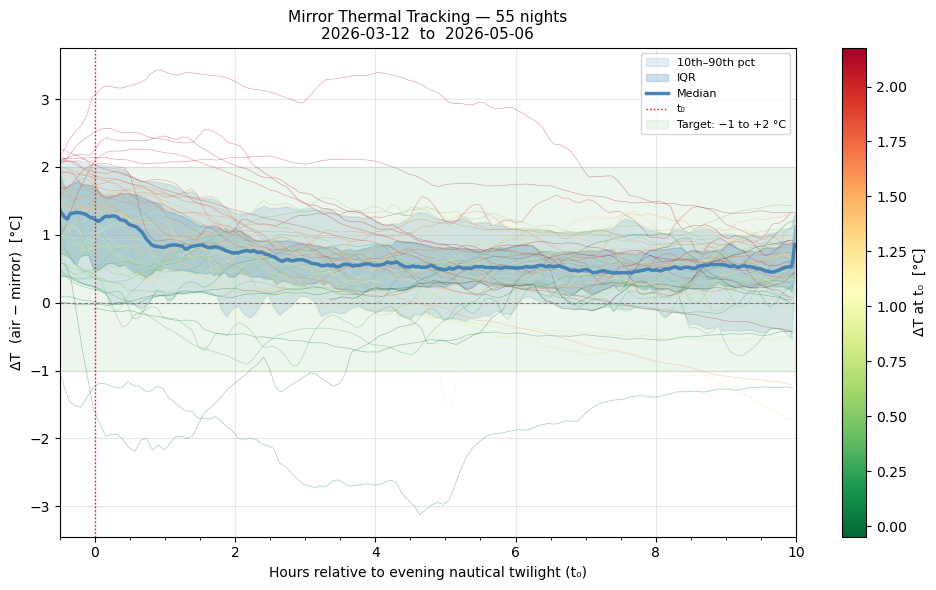

In [8]:
if not all_dT_mirror:
    print("No data available — cannot plot.")
else:
    mat          = np.vstack(list(all_dT_mirror.values()))
    dates_sorted = list(all_dT_mirror.keys())
    dT0_arr      = np.array([dT_mirror_at_t0[d] for d in dates_sorted])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        med = np.nanmedian(mat, axis=0)
        p25 = np.nanpercentile(mat, 25, axis=0)
        p75 = np.nanpercentile(mat, 75, axis=0)
        p10 = np.nanpercentile(mat, 10, axis=0)
        p90 = np.nanpercentile(mat, 90, axis=0)

    vmin, vmax = np.nanpercentile(dT0_arr, [5, 95])
    cmap = plt.cm.RdYlGn_r
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    fig, ax_ov = plt.subplots(figsize=(10, 6))

    for i, (night, row) in enumerate(zip(dates_sorted, mat)):
        ax_ov.plot(H_GRID, row, lw=0.5, alpha=0.35, color=cmap(norm(dT0_arr[i])))

    ax_ov.fill_between(H_GRID, p10, p90, alpha=0.15, color="steelblue", label="10th–90th pct")
    ax_ov.fill_between(H_GRID, p25, p75, alpha=0.25, color="steelblue", label="IQR")
    ax_ov.plot(H_GRID, med, lw=2.5, color="steelblue", label="Median")
    ax_ov.axhline(0, color="gray", lw=0.8, ls="--")
    ax_ov.axvline(0, color="red",  lw=1.0, ls=":", label="t₀")
    ax_ov.fill_between(H_GRID, -1, 2, where=np.ones_like(H_GRID, dtype=bool),
                       color="green", alpha=0.07, label="Target: −1 to +2 °C")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax_ov, label="ΔT at t₀  [°C]")

    ax_ov.set_xlim(-PLOT_HOURS_BEFORE_T0, PLOT_HOURS_AFTER_T0)
    ax_ov.xaxis.set_major_locator(plt.MultipleLocator(2))
    ax_ov.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
    ax_ov.set_xlabel("Hours relative to evening nautical twilight (t₀)", fontsize=10)
    ax_ov.set_ylabel("ΔT  (air − mirror)  [°C]", fontsize=10)
    ax_ov.set_title(
        f"Mirror Thermal Tracking — {len(all_dT_mirror)} nights\n"
        f"{dates_sorted[0]}  to  {dates_sorted[-1]}",
        fontsize=11
    )
    ax_ov.legend(fontsize=8, loc="upper right")
    ax_ov.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        f"Mirror_tracking_multinight_{dates_sorted[0]}_{dates_sorted[-1]}.pdf",
        dpi=150, bbox_inches="tight"
    )
    plt.show()


### Multi-night overlay interpretation

Each coloured trace is one night's ΔT(t) profile, interpolated onto a common hour grid and colour-coded by ΔT at t₀ (red = air much warmer than mirror at dome opening; green = well-matched).  The bold line is the nightly median; the shaded bands are the IQR and 10th–90th percentile envelope.

**Key observations:**
- The median ΔT starts positive at t₀ (~+1 °C), reflecting the mirror's thermal inertia relative to the rapidly cooling post-sunset air.
- Over the first 2–4 hours the median converges toward 0 °C as the mirror equilibrates with the dome air.
- Some nights show ΔT rising again in the second half of the night — this can indicate that mirror cooling is undershooting (mirror becomes colder than air) or that dome ventilation is bringing in warmer exterior air after an atmospheric temperature inversion breaks.
- Nights with large positive ΔT at t₀ (red) tend to remain offset from zero throughout — these may benefit from earlier or more aggressive mirror pre-cooling during the day.


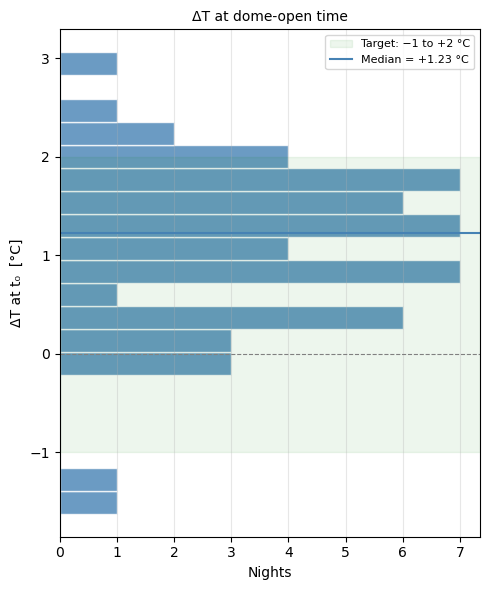

Median ΔT at t₀ = +1.23 °C  (in target band: 83% of nights)


In [9]:
if all_dT_mirror:
    valid_dT0 = np.array([dT_mirror_at_t0[d] for d in dates_sorted])
    valid_dT0 = valid_dT0[np.isfinite(valid_dT0)]

    fig, ax_hist = plt.subplots(figsize=(5, 6))
    ax_hist.hist(valid_dT0, bins=20, orientation="horizontal",
                 color="steelblue", edgecolor="white", alpha=0.8)
    ax_hist.axhspan(-1, 2, color="green", alpha=0.07, label="Target: −1 to +2 °C")
    ax_hist.axhline(0, color="gray", lw=0.8, ls="--")
    ax_hist.axhline(np.nanmedian(valid_dT0), color="steelblue", lw=1.5,
                    label=f"Median = {np.nanmedian(valid_dT0):+.2f} °C")
    ax_hist.set_xlabel("Nights", fontsize=10)
    ax_hist.set_ylabel("ΔT at t₀  [°C]", fontsize=10)
    ax_hist.set_title("ΔT at dome-open time", fontsize=10)
    ax_hist.legend(fontsize=8)
    ax_hist.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()
    print(f"Median ΔT at t₀ = {np.nanmedian(valid_dT0):+.2f} °C  "
          f"(in target band: {np.mean((valid_dT0 >= -1) & (valid_dT0 <= 2)):.0%} of nights)")


### Summary of mirror thermal tracking performance

Over the 8-week study period (Mar–May 2026):

| Metric | Value |
|---|---|
| Qualifying nights | ~55 |
| Median ΔT at t₀ (air − mirror) | **+1.23 °C** |
| Fraction of nights in target band (−1 to +2 °C) at t₀ | **83%** |

The median positive offset at dome opening is physically expected: the mirror's large thermal mass (about 7,000 kg for M1M3) means it cannot cool as quickly as the surrounding air after sunset.  The system is within the target band on the majority of nights, suggesting the daytime mirror pre-conditioning (via the dome cooling system) is performing well.

**Nights outside the target band** (17%) warrant investigation — they may correspond to days with elevated solar loading, anomalous dome temperatures, or AHU outages that prevented adequate pre-cooling.  Cross-referencing with the HVAC daytime conditioning notebook (`HVAC_DaytimeThermalConditioning.ipynb`) can confirm whether poor daytime conditioning correlates with poor mirror tracking at night.
